In [2]:
import numpy as np
import helper_lmm as hl
from lmm_classes import LMMSimulator, ZeroCouponBondPricer

import warnings
warnings.filterwarnings('ignore')

In [3]:
first_forward_rate = 0.0469 #also spot rate, won't really be used, alternatively, one could use it for discounting, but here it won't be

initial_forward_rates = np.array([
    0.050114, 0.055973, 0.058387, 0.060027, 0.061315, 0.062779, 0.062747, 0.062926,
    0.062286, 0.063099, 0.063554, 0.064257, 0.064784, 0.065312, 0.063976, 0.062997,
    0.06184, 0.060682, 0.05936
])

market_caplet_vols = np.array([
    np.nan, 0.180253, 0.191478, 0.186154, 0.177294, 0.167887, 0.158123, 0.152688, 0.148709,
    0.144703, 0.141259, 0.137982, 0.134708, 0.131428, 0.128148, 0.1271, 0.126822,
    0.126539, 0.126257, 0.12597
])

valid_mask = ~np.isnan(market_caplet_vols)
market_volas_clean = market_caplet_vols[valid_mask]
n_periods = len(market_volas_clean)

tau = 0.25
T = np.arange(1, n_periods + 1) * 0.25 + 0.25
t = 0  # Current time (assuming we're at t=0)
option_expiries = np.arange(2, 20) * tau    # a grid that goes as follows 0.5..4.75
swap_tenors    = np.arange(2, 18) * tau     # a grid that goes as follows 0.5..4.25

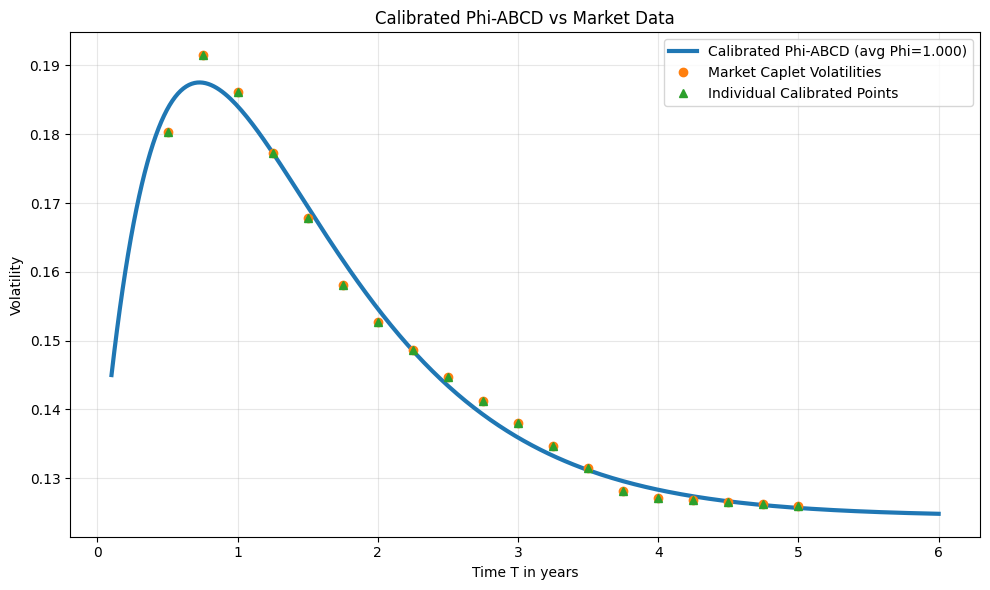

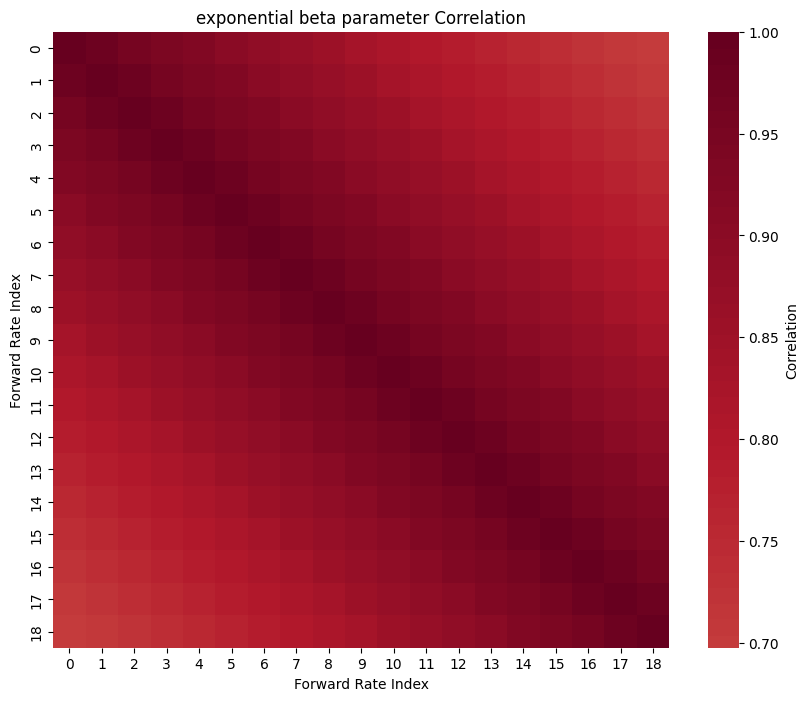

In [4]:
result3 = hl.calibrate_method3(T, market_volas_clean)
methods = [
    ("Two-step Approach", result3)
]

calibration_results = {}
for name, result in methods:
    n_periods = len(T)
    phi_values = result.x[:n_periods]
    a, b, c, d = result.x[n_periods:]
    
    model_vols = hl.phi_abcd_model(result.x, T)
    rmse_val = hl.rmse(market_volas_clean, model_vols)
    
    calibration_results[name] = {
        'phi': phi_values,
        'a': a, 'b': b, 'c': c, 'd': d,
        'model_vols': model_vols,
        'rmse': rmse_val,
        'objective': result.fun
    }
best_calibration = calibration_results['Two-step Approach']
phi_values = best_calibration['phi']
abcd_params = [best_calibration['a'], best_calibration['b'], best_calibration['c'], best_calibration['d']]

T_range, model_vols_extended, individual_model_vols = hl.plot_phi_abcd_volatility_function2(
    calibration_results, 
    market_volas_clean,
    T,
    best_method= 'Two-step Approach',
    T_range=np.linspace(0.1, 6.0, 300)
)

beta = 0.02
n_rates = 19
calibrated_corr_3p = hl.correlation_matrix_parametrization(beta, n_rates)
hl.plot_correlation_matrix(calibrated_corr_3p, f"exponential beta parameter Correlation")

In [5]:
lmm = LMMSimulator(
    initial_rates=initial_forward_rates,
    phi_values=phi_values,
    abcd_params=abcd_params,
    correlation_matrix=calibrated_corr_3p,
    rate_maturities=T 
)

time_grid, paths, L_fix_snap = lmm.simulate_all_rates_jointly(
    n_paths=1000, T_max=5.0, n_time_steps=570, seed=42,
    freeze_mode="nan", return_fixings=True
)

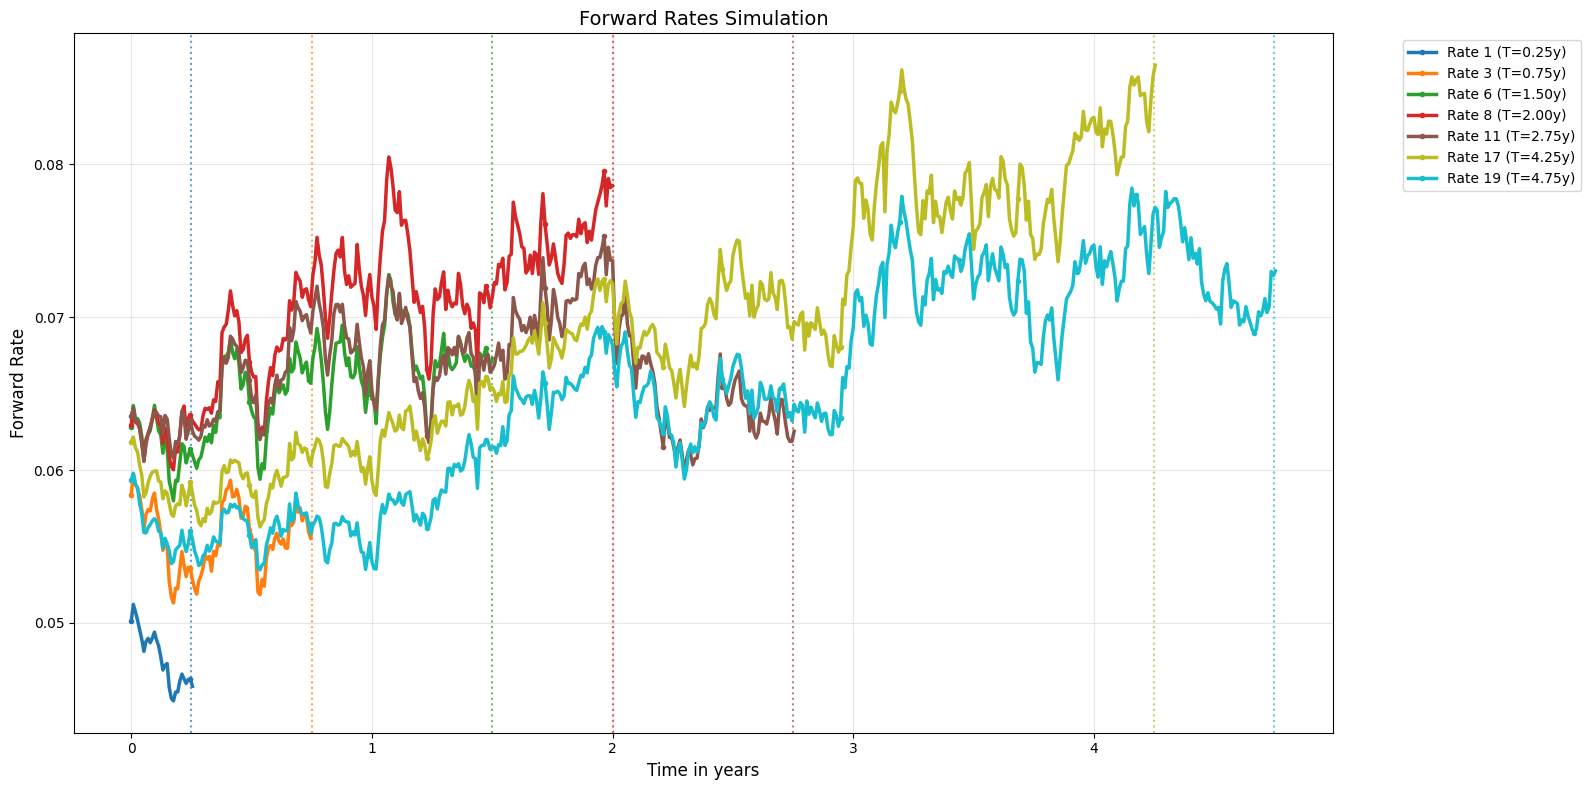

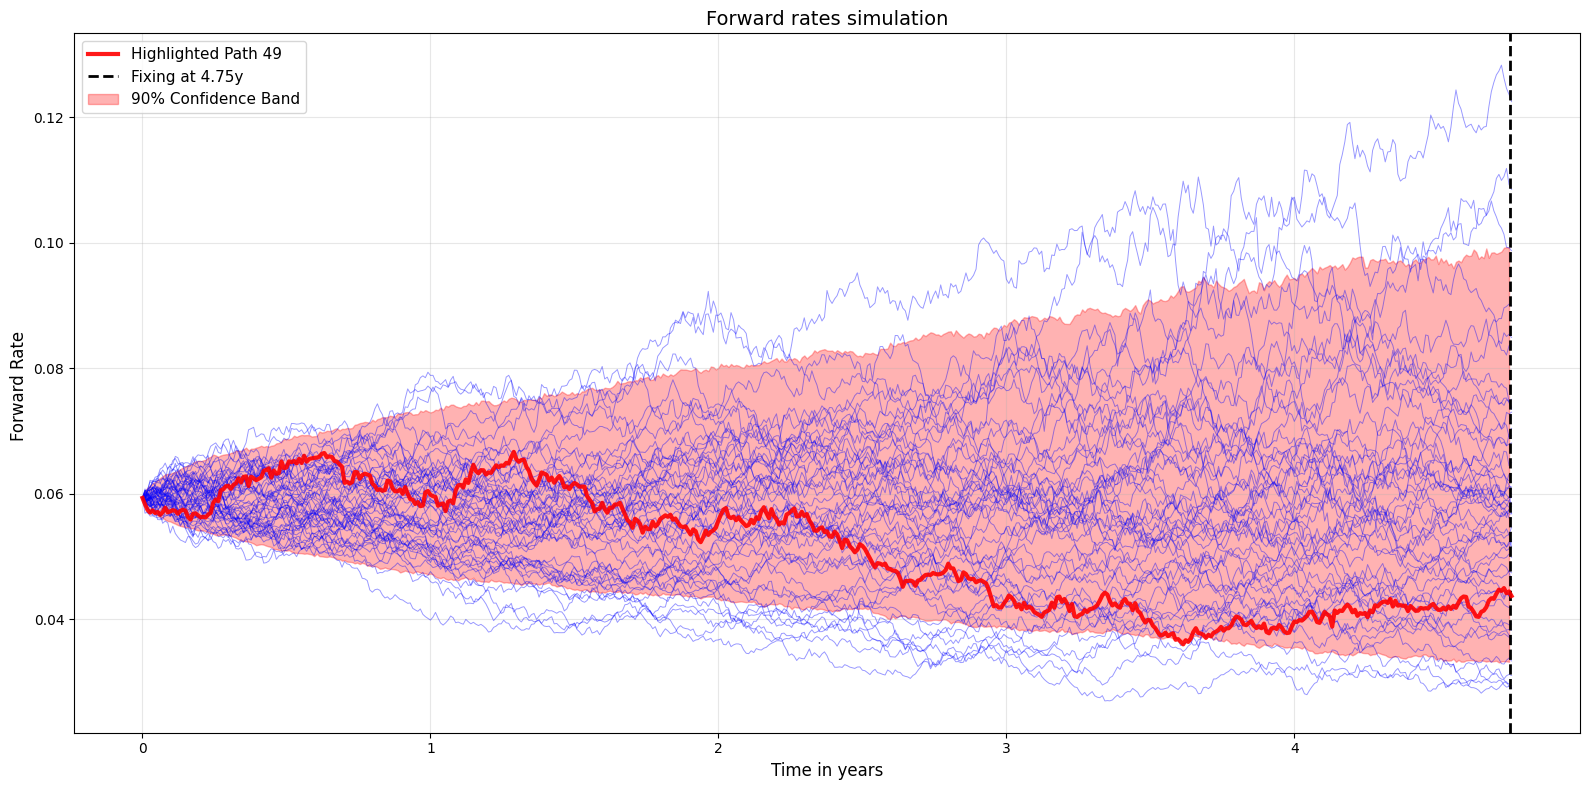

In [6]:
settlement = T - tau

hl.plot_multiple_rates(
    time_grid, paths, settlement, rate_index = [0, 2, 5, 7, 10, 16, 18],
    selected_path=1,      # Which path to highlight
    max_rates=19,         # How many rates to show in plot
)

percentile_5 = np.percentile(paths, 5, axis=0)
percentile_95 = np.percentile(paths, 95, axis=0)

hl.plot_simulated_rate2(
    time_grid, paths, settlement,
    selected_path=49,
    selected_rate=18,
    n_paths_to_show=50,
    percentile_5=percentile_5,
    percentile_95=percentile_95,
)

In [7]:
zcb_pricer = ZeroCouponBondPricer(
    lmm_simulator=lmm,
    forward_rates=initial_forward_rates,
    rate_maturities=settlement,
    tau=tau
)
bond_maturities = [1.0, 2.0, 3.0, 4.0, 5.0]
pricing_times = [0.0, 1.0]

comparison_results = zcb_pricer.compare_analytical_vs_mc(
    time_grid, paths, pricing_times, bond_maturities
)

hl.create_zcb_comparison_table(comparison_results)

Pricing Time Bond Maturity Analytical   MC Mean      Difference  
--------------------------------------------------------------------------------
0.00         1.00         0.945791     0.945791     0.000000000000
0.00         2.00         0.888969     0.888969     0.000000000000
0.00         3.00         0.834856     0.834856     0.000000000000
0.00         4.00         0.783290     0.783290     0.000000000000
0.00         5.00         0.748726     0.748726     0.000000000000
1.00         2.00         0.939921     0.940209     0.000287737687
1.00         3.00         0.882706     0.883345     0.000638121739
1.00         4.00         0.828185     0.829105     0.000920637163
1.00         5.00         0.791640     0.792706     0.001065723116


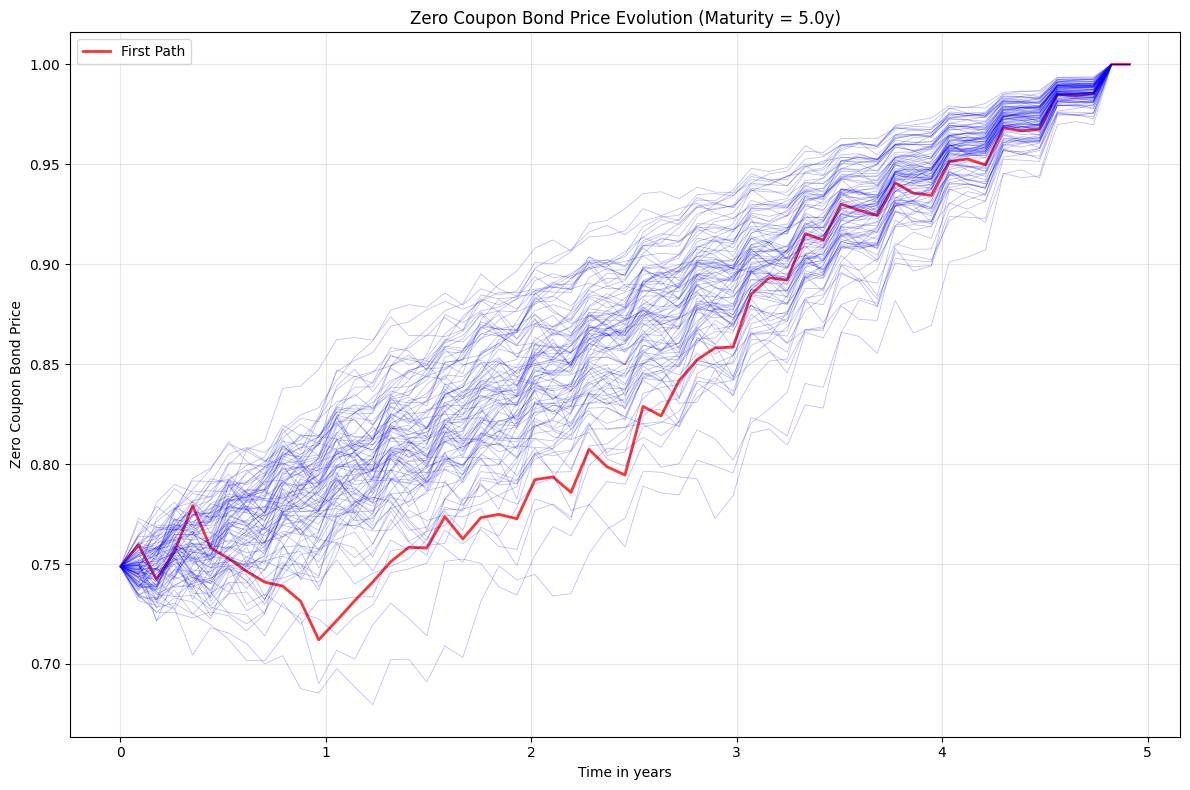

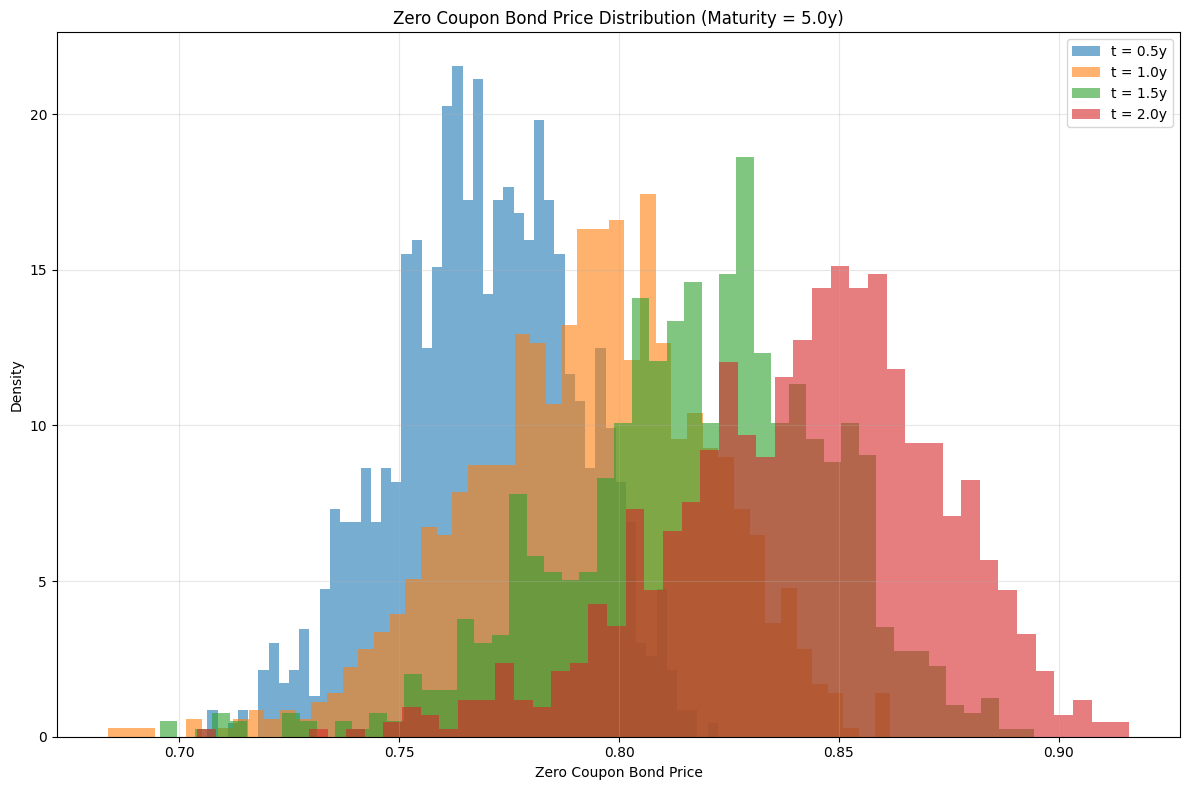

In [8]:
hl.plot_zcb_price_evolution(zcb_pricer, time_grid, paths, bond_maturity=5.0, n_paths_to_show=100)

In [9]:
P0T = hl.discount_factors_from_forwards(initial_forward_rates, tau=0.25)

strike_rate = 0.06
Notional = 10000
cap_price_mc2, caplet_prices_mc2 = hl.price_cap_monte_carlo_spot_measure(
    time_grid, paths, strike_rate, T
)

cap, caplets_black, vars = hl.price_cap_black_with_P0T(
    initial_forward_rates, phi_values, abcd_params, strike_rate, T, P0T
)

Ncaplet_prices_mc2 = caplet_prices_mc2 * Notional
Ncaplets_black = caplets_black * Notional
Ncap_price_mc2 = cap_price_mc2 * Notional
Ncap = cap * Notional

print("Monte Carlo  | Black Price | Error")

for i, j in zip(Ncaplet_prices_mc2, Ncaplets_black):
    print(f"{i:.6f}     | {j:.6f}    | {j - i:.6f}")

print(f"Cap Price (MC Method): {Ncap_price_mc2:.6f}")      
print(f"Cap Price (Black): {Ncap:.6f}")

Monte Carlo  | Black Price | Error
0.023720     | 0.363253    | 0.339533
2.768076     | 4.498922    | 1.730846
6.476398     | 8.205186    | 1.728788
9.675274     | 11.169151    | 1.493877
12.282492     | 13.592032    | 1.309540
14.662261     | 16.079118    | 1.416856
16.041448     | 16.603766    | 0.562318
17.319415     | 17.383007    | 0.063591
16.802827     | 16.896862    | 0.094035
17.952022     | 18.272630    | 0.320608
18.595232     | 19.043198    | 0.447966
19.753261     | 20.018417    | 0.265156
19.767098     | 20.641080    | 0.873982
20.194215     | 21.166109    | 0.971894
18.768838     | 19.430644    | 0.661806
17.628841     | 18.296233    | 0.667392
16.224361     | 16.992469    | 0.768108
15.118332     | 15.747401    | 0.629068
14.054993     | 14.391876    | 0.336882
Cap Price (MC Method): 274.109106
Cap Price (Black): 288.791354


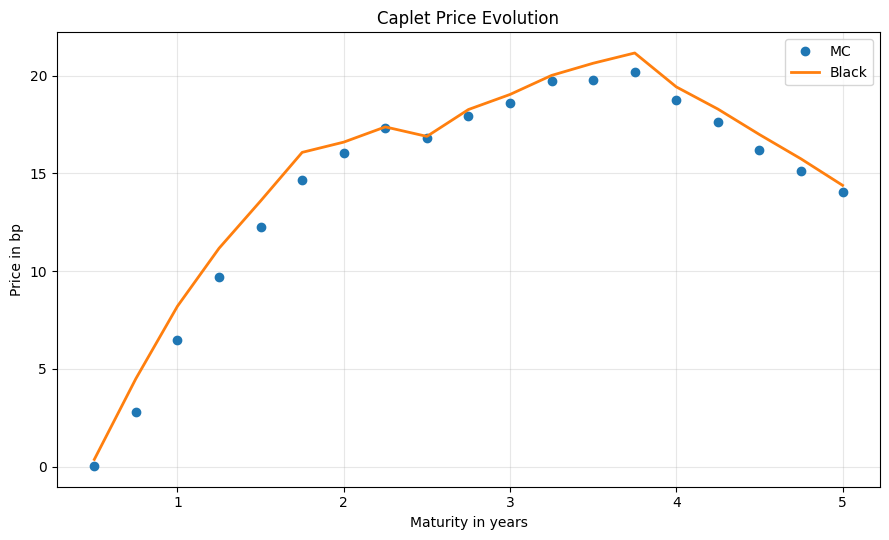

In [10]:
hl.plot_caplet_prices_vs_maturity(
    T,
    Ncaplet_prices_mc2,
    caplet_prices_black=Ncaplets_black,
    caplet_se=None
)

# mc_implied_vols, black_implied_vols = hl.plot_caplet_implied_volatilities(
#     maturities=T,
#     mc_caplet_prices=caplet_prices_mc2,
#     black_caplet_prices=caplets_black,
#     forward_rates=initial_forward_rates,
#     strike_rate=strike_rate,
#     discount_factors=P0T,
#     tau=0.25
# )

In [11]:
model_vol_surface = hl.calculate_model_swaption_matrix(
    forward_rates=initial_forward_rates,
    phi_values=phi_values,
    abcd_params=abcd_params,
    correlation_matrix=calibrated_corr_3p,
    option_expiries=option_expiries,
    swap_tenors=swap_tenors,
    maturities=T,
    tau=0.25,
    return_black_vol=True
)

Calculated 152/288 swaptions (52.8%). NaNs: 136


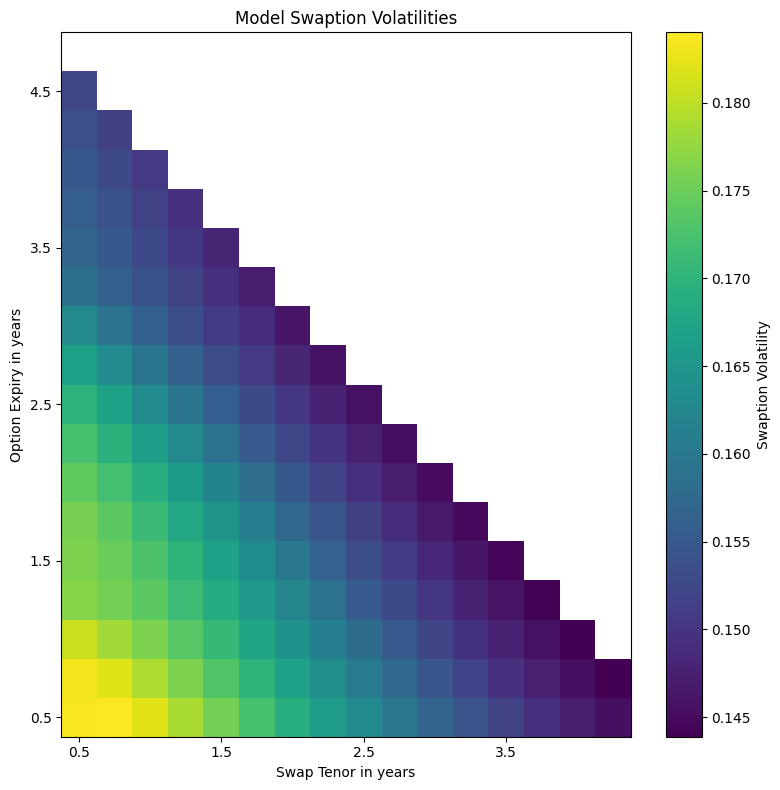

In [12]:
hl.plot_swaption_matrix(model_vol_surface, option_expiries, swap_tenors)

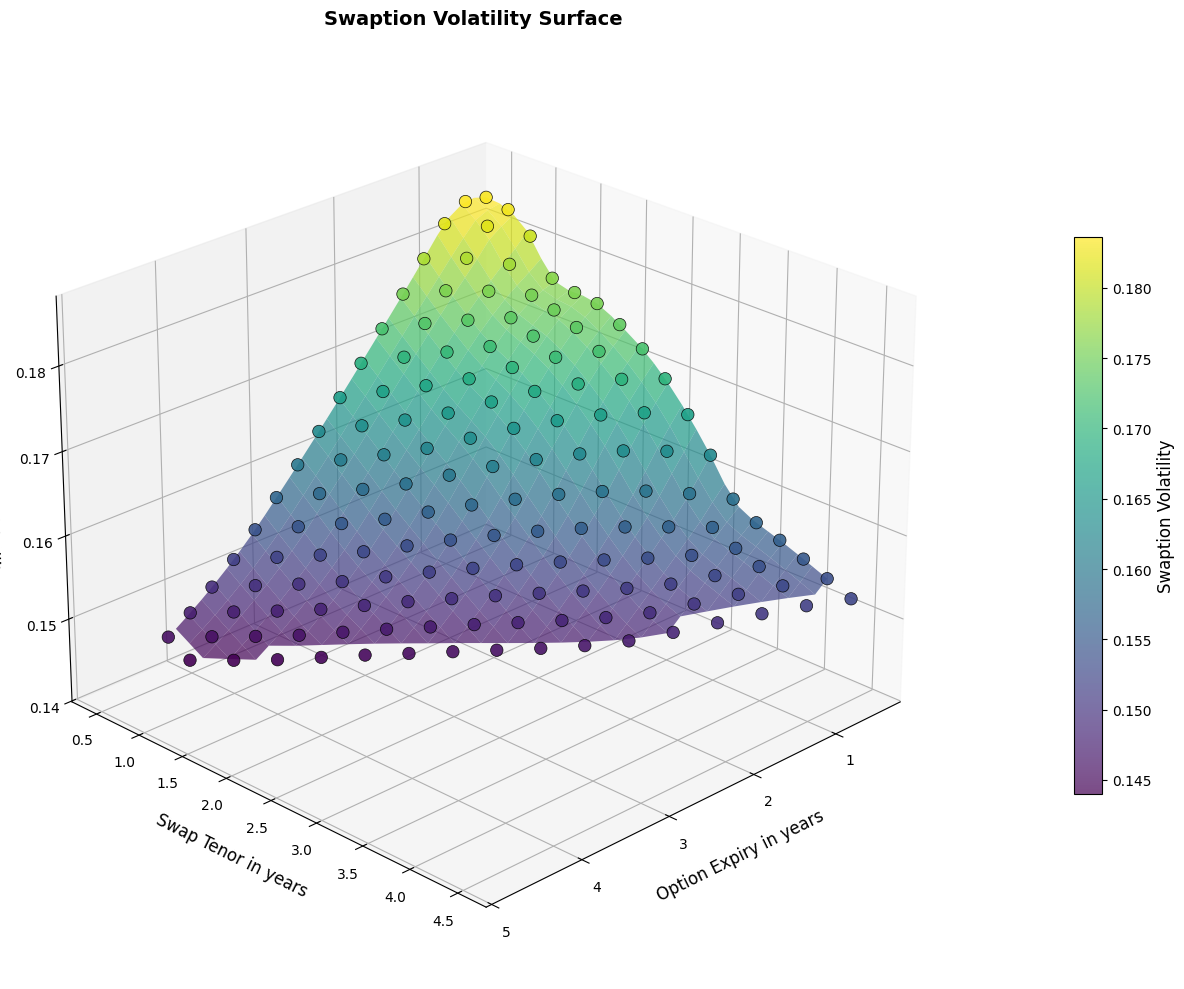

In [13]:
hl.plot_3d_volatility_surface(
    model_vol_surface, 
    option_expiries, 
    swap_tenors
)